# Car Price Prediction with XGBoost
This notebook demonstrates a modular approach to predicting car prices using XGBoost regression. Each step is explained and grouped for clarity.

## 1. Import Required Libraries
We import XGBoost, pandas, scikit-learn utilities, and numpy for data handling and modeling.

In [1]:
import xgboost as xgb
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt
from xgboost import plot_tree

## 2. Load and Preprocess Data
We load the cleaned car dataset and drop the 'name' column, which is not useful for modeling.

In [2]:
df = pd.read_csv("D:/Coding/Exploratory_Data_Analysis/data/Provided/Clean/cleaned_data.csv")
df = df.drop('name', axis=1)
df.head()

,price,mileage,engine_cc,fuel,kilometer_run,is_automatic,is_4WD,age
0,2475000.0,14.0,1400.0,1,42000.0,0,0,10
1,750000.0,11.0,1399.0,1,87412.0,1,0,20
2,700000.0,12.0,2956.0,2,60000.0,0,0,12
3,600000.0,14.0,1200.0,2,33516.0,0,1,8
4,375.0,17.0,1200.0,1,2400.0,1,0,6


## 3. Split Data and Log Transform Target
We split the data into training and test sets, and apply a log transform to the target variable (price) to stabilize variance.

In [3]:
X = df.drop('price', axis=1)
y = df['price']
X = X.apply(pd.to_numeric, errors='coerce')
y = y.apply(pd.to_numeric, errors='coerce')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

In [4]:
print(y.isna().sum())

0


## 4. Initialize and Train XGBoost Model
We set up the XGBoost regressor with chosen hyperparameters and fit it to the training data.

In [5]:
model = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
model.fit(X_train, y_train_log)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


## 5. Predict and Evaluate
We predict car prices on the test set and evaluate the model using mean squared error (MSE).

In [6]:
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test_log, y_pred)
print("MSE:", mse)

MSE: 0.2535492775571915


d:\Coding\Exploratory_Data_Analysis\.EDA\Lib\site-packages\xgboost\plotting.py:267: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


ExecutableNotFound: failed to execute WindowsPath('dot'), make sure the Graphviz executables are on your systems' PATH

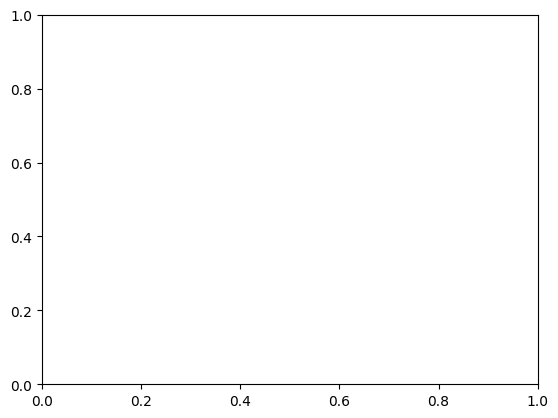

In [7]:
plot_tree(model, num_trees=0)
plt.show()

Save

In [ ]:
model.save_model('D:/Coding/Exploratory_Data_Analysis/models/provided_data_model.json')